# Code to train model on recognizing different hand signs.

In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm
import os
MAIN_DIR = os.path.dirname(os.path.abspath('__file__'))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

In [2]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {DEVICE} device")

Using cuda device


# Dataset Generation

In [3]:
#load data
data_dict = pickle.load(open('data.p', 'rb'))

data = data_dict['data']
labels = data_dict['labels']

In [4]:
print(data[0])

[[0.1867212951183319, 0.3454219400882721], [0.2105410099029541, 0.26477137207984924], [0.20549911260604858, 0.15397879481315613], [0.21788015961647034, 0.07708999514579773], [0.23387181758880615, 0.018842846155166626], [0.09629860520362854, 0.15894314646720886], [0.0409332811832428, 0.09501919150352478], [0.01899704337120056, 0.04326501488685608], [0.0, 0.0], [0.07370966672897339, 0.19415590167045593], [0.09204792976379395, 0.10325053334236145], [0.14165344834327698, 0.1702766716480255], [0.1359681487083435, 0.21503719687461853], [0.056985318660736084, 0.23565319180488586], [0.08637365698814392, 0.16280612349510193], [0.1318027675151825, 0.22507265210151672], [0.11516422033309937, 0.25875458121299744], [0.043659061193466187, 0.2869074046611786], [0.0649803876876831, 0.22070887684822083], [0.10260820388793945, 0.2523670494556427], [0.09099319577217102, 0.2871399223804474]]


In [5]:
class SignDataset(Dataset):
    def __init__(self, data, labels):
        self.data = [torch.tensor(seq, dtype=torch.float32).flatten() for seq in data]
        self.labels = torch.tensor([int(label) for label in labels], dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

    @property
    def classes(self):
        return self.data.classes

In [6]:
dataset = SignDataset(data, labels)
len(dataset)

1367

In [7]:
landmarks, label = dataset[1000]
print(landmarks)
print(label)

tensor([0.0000, 0.2504, 0.0608, 0.1917, 0.0872, 0.1304, 0.1083, 0.0946, 0.1264,
        0.0640, 0.0285, 0.0054, 0.1289, 0.0149, 0.1580, 0.0618, 0.1684, 0.1002,
        0.0236, 0.0000, 0.1461, 0.0437, 0.1519, 0.1136, 0.1464, 0.1628, 0.0291,
        0.0103, 0.1518, 0.0586, 0.1503, 0.1245, 0.1373, 0.1714, 0.0414, 0.0331,
        0.1339, 0.0312, 0.1865, 0.0344, 0.2311, 0.0391])
tensor(28)


In [8]:
#Split train and validation dataset
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])
print(len(train_dataset))
print(len(test_dataset))

1094
273


# DataLoader Generation

In [9]:
train_dataloader = DataLoader(dataset, batch_size = 128, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = 64, shuffle = True)

In [10]:
for data, label in train_dataloader:
    break

In [11]:
# 128 datapoints per batch, 21 landmarks [x, y] flatten to become shape 42
# Roughly 10 batches per epoch for training data
print(data.shape)

torch.Size([128, 42])


In [12]:
print(label.shape)

torch.Size([128])


# Neural Network Construction

In [13]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2*21, 100),
            nn.ReLU(),
            nn.Linear(100, 160),
            nn.ReLU(),
            nn.Linear(160, 26),
            nn.LogSoftmax(dim = 1)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=26, bias=True)
    (5): LogSoftmax(dim=1)
  )
)


In [15]:
ex_output = model(data)
ex_output.shape # [batch_size, num_classes]

torch.Size([128, 26])

# Loss & Optimizer

In [16]:
#Loss
criterion = nn.CrossEntropyLoss()
#Optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.001)

criterion(ex_output, label)

In [17]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Load Pre-trained Model

In [18]:
def load_checkpoint(filename: str, model: object, optimizer: object) -> (object, object): 
    print("Loading checkpoint")
    checkpoint = torch.load(filename)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    #If save more things, get more from the dict and then return
    return model, optimizer

In [19]:
model, optimizer = load_checkpoint("model_checkpoint_2_1.pth.rar", model, optimizer)

Loading checkpoint


In [20]:
model

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=26, bias=True)
    (5): LogSoftmax(dim=1)
  )
)

In [21]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Update Classification Classes 26 -> 29

In [22]:
old_linear_nn_model = model.net[4]
in_features = old_linear_nn_model.in_features

print(old_linear_nn_model)
print(in_features)

Linear(in_features=160, out_features=26, bias=True)
160


In [23]:
new_linear_nn_model = nn.Linear(in_features, 29)
print(new_linear_nn_model)

Linear(in_features=160, out_features=29, bias=True)


In [24]:
# copy the old weights (for the first 26 classes)
with torch.no_grad():
    new_linear_nn_model.weight[:26] = old_linear_nn_model.weight
    new_linear_nn_model.bias[:26] = old_linear_nn_model.bias

In [25]:
print(new_linear_nn_model.weight[27])

tensor([ 0.0166,  0.0101, -0.0452,  0.0358, -0.0717, -0.0535, -0.0520, -0.0063,
         0.0539,  0.0375,  0.0279, -0.0033,  0.0621, -0.0701,  0.0275,  0.0029,
         0.0518,  0.0187, -0.0557,  0.0476, -0.0305,  0.0408, -0.0452, -0.0132,
         0.0465, -0.0039,  0.0650, -0.0767,  0.0193, -0.0511, -0.0596,  0.0655,
         0.0099, -0.0539, -0.0160,  0.0570,  0.0543, -0.0653, -0.0068,  0.0305,
         0.0321,  0.0340,  0.0188,  0.0259,  0.0411,  0.0628,  0.0650, -0.0601,
        -0.0057, -0.0450, -0.0360, -0.0251, -0.0281,  0.0734,  0.0507,  0.0037,
        -0.0720,  0.0539, -0.0401,  0.0596,  0.0166,  0.0281, -0.0103, -0.0045,
        -0.0393, -0.0128,  0.0214,  0.0059, -0.0247, -0.0220,  0.0531,  0.0202,
         0.0003,  0.0225,  0.0535, -0.0763,  0.0138,  0.0163, -0.0787,  0.0052,
         0.0107,  0.0567,  0.0700,  0.0669, -0.0458, -0.0311,  0.0451, -0.0393,
        -0.0095, -0.0398, -0.0513, -0.0049, -0.0359, -0.0721, -0.0333,  0.0430,
         0.0184,  0.0321,  0.0349,  0.04

In [26]:
model.net[4] = new_linear_nn_model

model

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=29, bias=True)
    (5): LogSoftmax(dim=1)
  )
)

In [27]:
# Freezed layer won't be updated during training
for param in model.parameters():
    param.requires_grad = True  # freeze everything

model.net[4].weight.requires_grad = True  # unfreeze full output layer
model.net[4].bias.requires_grad = True

In [28]:
def mask_old_class_grads(grad):
    mask = torch.zeros_like(grad)
    mask[26:] = 1  # Allow gradient flow only to classes 26–28
    return grad * mask

model.net[4].weight.register_hook(mask_old_class_grads)
model.net[4].bias.register_hook(mask_old_class_grads)

# Update optimizer 26 -> 29

In [29]:
new_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.Adam(new_params, lr=1e-4)

# Continue Model Training

In [30]:
num_epochs = 250
train_losses, val_losses = [], []

model.to(DEVICE)

for epoch in range(num_epochs):
    model.train() #setting model mode .train or .eval
    running_loss = 0.0
    for landmarks, labels in tqdm(train_dataloader, desc = "Training loop"):
        landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(landmarks)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)

    #Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for landmarks, labels in tqdm(test_dataloader, desc = "Validation loop"):
            landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)
            outputs = model(landmarks)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(test_dataloader.dataset)
    val_losses.append(val_loss)

    print("Epoch %d out of %s - Train loss: %s , Validation loss: %s" % (epoch + 1, num_epochs, train_loss, val_loss))

Training loop:   0%|          | 0/11 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 out of 250 - Train loss: 13.84805550188066 , Validation loss: 13.585239351014078


Training loop:   0%|          | 0/11 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 249 out of 250 - Train loss: 0.022706701637578864 , Validation loss: 0.02077924415823959


Training loop:   0%|          | 0/11 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 250 out of 250 - Train loss: 0.02246287615387956 , Validation loss: 0.02055281709756825


# Visualize

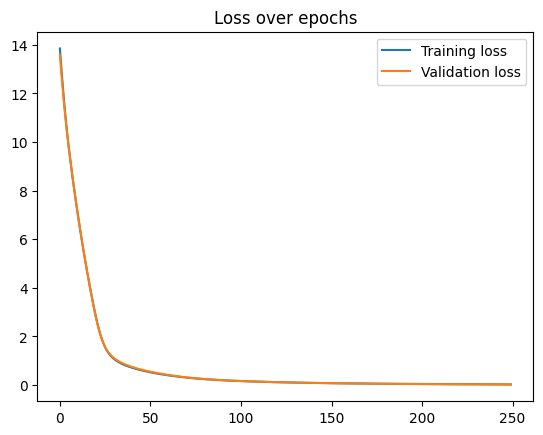

In [31]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

# Save Model State for Further Training Later

In [ ]:
checkpoint = {'state_dict' : model. state_dict(), 'optimizer': optimizer.state_dict()}

In [ ]:
def save_checkpoint(state, filename = "model_checkpoint_3.pth.rar"):
    print("Saving current checkpoint")
    torch.save(state, filename)

In [ ]:
save_checkpoint(checkpoint)

# Save Model for inferencing

In [ ]:
# Save model for model inference
# Save the model's state_dict
model_scripted = torch.jit.script(model) # Export to TorchScript
model_scripted.save('model_3.pth.rar') # Save

# Test Trained model

In [32]:
import mediapipe as mp
import cv2

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.6, max_num_hands = 1)

In [33]:
def predict(model, input_landmarks):
    model.eval()
    with torch.no_grad():
        input_landmarks = torch.tensor(input_landmarks, dtype=torch.float32).flatten()
        input_landmarks = input_landmarks.unsqueeze(0).to(DEVICE)
        predictions_log = model(input_landmarks)
        predictions_prob = torch.exp(predictions_log)
        max_probability_predicted, max_probability_index = torch.max(predictions_prob, dim=1)
    return max_probability_index.item()

In [34]:
def hand_landmarks_detection(path: str) -> list:
    data_aux, x_, y_ = [], [], []

    img = cv2.imread(path)
    # Flip image horizontally to correctly identify left hand being used in the collected images
    #img = cv2.flip(img, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    # Only use the images with left hand for dataset generation => only 21 points for landmarks
    if results.multi_hand_landmarks and results.multi_handedness[0].classification[0].label == 'Left':
        for hand_landmarks in results.multi_hand_landmarks:
            # Write images with overlapped hand landmarks on the original data collected.
            mp_drawing.draw_landmarks(
                img,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,  
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())
            
            for i in range(len(hand_landmarks.landmark)):
                x = hand_landmarks.landmark[i].x
                y = hand_landmarks.landmark[i].y

                x_.append(x)
                y_.append(y)

        # To reduce variability for different positions of the hand on the screen, each data point subtracts the lowest x and y position per frame.
        # Essentially reducing the positions of all landmarks to be start at the bottom left conner of the image.
        for i in range(len(hand_landmarks.landmark)):
            x = hand_landmarks.landmark[i].x
            y = hand_landmarks.landmark[i].y
            data_aux.append([x - min(x_), y - min(y_)])
    return data_aux
        

In [35]:
test_folder = "neural_net_model_test_set_after_ver3"
counter = correct_points = 0
for char_folder in os.listdir(test_folder):
    correct_result = char_folder
    for pic in os.listdir(os.path.join(test_folder, char_folder)):
        hand_landmarks = hand_landmarks_detection(os.path.join(test_folder, char_folder, pic))
        if hand_landmarks:
            counter += 1
            predicted_result = predict(model, hand_landmarks)
            print(predicted_result)
            print("--------------")
            if str(predicted_result) == char_folder:
                correct_points += 1

print(counter)
print(correct_points)
print("Accuracy: " + str(correct_points/counter))
        

28
--------------
28
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
20
--------------
20
--------------
20
--------------
20
--------------
20
--------------
20
--------------
20
--------------
20
--------------
20
--------------
20
--------------
21
--------------
21
--------------
21
--------------
21
--------------
21
--------------
21
--------------
21
--------------
21
--------------
21
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
26
--------------
12
--------------
12
--------------
12
--------------
12
--------------
12
--------------
12
--------------
13
--------------
13
--------------
13
--------------
13
--------------
13
--------------
28
--------------
28
--------------
28
--------------
28
--------------
28
--------------
28
-------